<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43126 entries, 0 to 43125
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   League      43126 non-null  object 
 1   Date        43126 non-null  object 
 2   Get         43126 non-null  object 
 3   Pay         43126 non-null  object 
 4   Value       43126 non-null  float64
 5   Confidence  43126 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.0+ MB

Removed all data that isn't using 'Chaos Orb' as the Pay value to simplify mining. Chaos orb is regarded as the standard trading currency by the community.


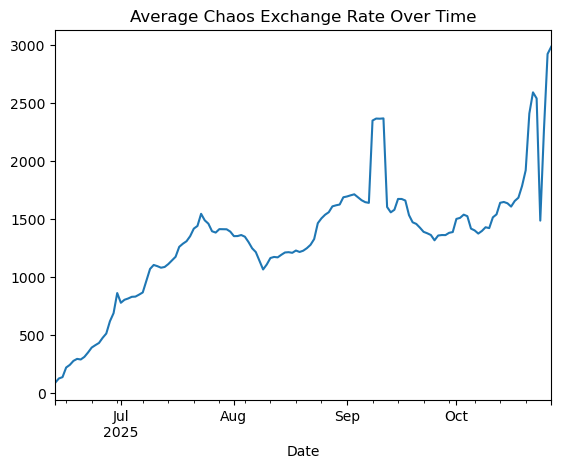

Shows that the relative value of chaos to all other currencies does change and trends upwards relatively


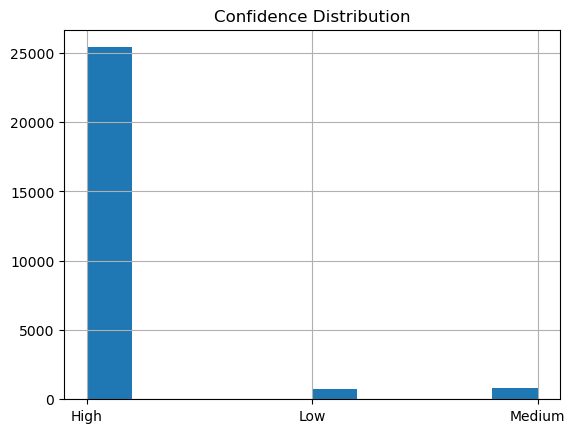

Graphs the average confidence, we can see that most trades are high confidence


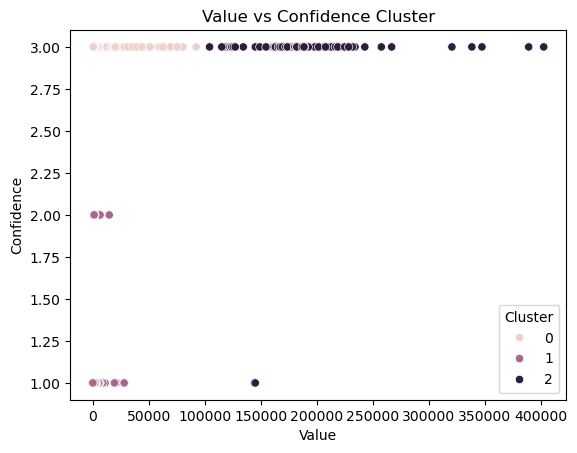

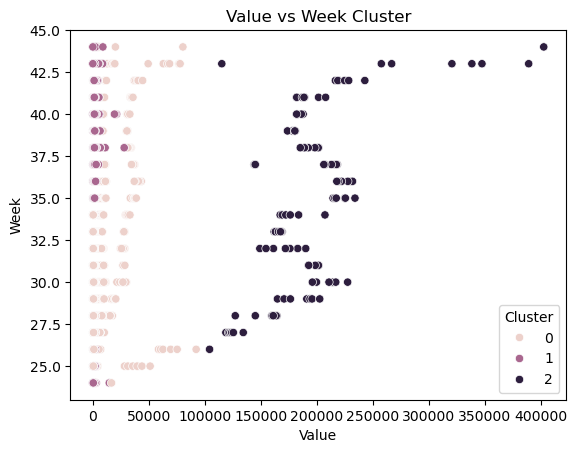

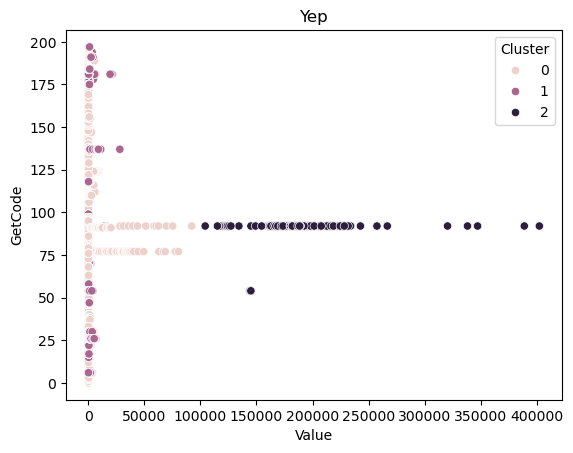

Most trades cluster around mid-range values.
High-value trades correspond to rare currencies, while low-value trades correspond to common currencies.
Confidence is generally high for expensive trades.


In [34]:
import pandas as pd
df = pd.read_csv("Mercenaries.currency.csv", sep=";")
df.head()
df.shape
df.info()
df.describe()

df.columns = [
    "League",
    "Date",
    "Get",
    "Pay",
    "Value",
    "Confidence"
]

df = df[df["Pay"] == "Chaos Orb"] #only using rows that are priced in chaos for normalization 
df.head()
len(df) #26906 rows priced in chaos

print("\nRemoved all data that isn't using 'Chaos Orb' as the Pay value to simplify mining. Chaos orb is regarded as the standard trading currency by the community.")
df["Date"] = pd.to_datetime(df["Date"]) #better for date storting

df.groupby("Get")["Value"].mean().sort_values(ascending=False) #Average exchange rate per currency

#exchange rate over time
df.groupby("Date")["Value"].mean().plot()
plt.title("Average Chaos Exchange Rate Over Time")
plt.show()

print("Shows that the relative value of chaos to all other currencies does change and trends upwards relatively")

#graphs the average confidence, we can see that most trades are high confidence
df["Confidence"].hist()
plt.title("Confidence Distribution")
plt.show()
print("Graphs the average confidence, we can see that most trades are high confidence")

#CLUSTERING --------------------------------------------
from sklearn.preprocessing import StandardScaler

conf_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

#cleaning data to be used in different clusters
df["ConfidenceNum"] = df["Confidence"].map(conf_mapping)

features = df[["Value", "ConfidenceNum"]]


scaler = StandardScaler()
scaled = scaler.fit_transform(features)


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Value", y="ConfidenceNum", hue="Cluster")
plt.xlabel("Value")
plt.ylabel("Confidence")
plt.title("Value vs Confidence Cluster")
plt.show()

#Value is numeric, Confidence was categorical → converted to numbers (Low=1, Medium=2, High=3).
#Features were scaled to make K-Means distances meaningful.
#Clustering reveals different market states based on trade value and confidence.


df["Date"] = pd.to_datetime(df["Date"])
df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week

features = df[["Value", "Week"]]
sns.scatterplot(data=df, x="Value", y="Week", hue="Cluster")
plt.xlabel("Value")
plt.ylabel("Week")
plt.title("Value vs Week Cluster")
plt.show()

df["GetCode"] = df["Get"].astype("category").cat.codes
features = df[["Value", "GetCode"]]
sns.scatterplot(data=df, x="Value", y="GetCode", hue="Cluster")
plt.xlabel("Value")
plt.ylabel("GetCode")
plt.title("Yep")
plt.show()

print("Most trades cluster around mid-range values.")
print("High-value trades correspond to rare currencies, while low-value trades correspond to common currencies.")
print("Confidence is generally high for expensive trades.")


